# Data Analysis for "Musical Encounters"

## Swarm Properties

### Justification

In research that involves multi-agent systems, we might be interested in figuring out *emergent properties* that arise from the interaction of multiple agents in an environment. Usually, it has to do with investigating the performance of the systems when some parameters change; for instance, if we have to solve several tasks in an environment, a performance metric would be the number of tasks solved per unit of time. You might think that, in a generic situation, if you add more agents, we will complete more tasks in less time, but in some cases, more agents would saturate the environment, and the performance would be reduced. Typically, we can figure this out through simulations, which is something that the **HS-ims app** helps us with.

In creative processes, like music improvisation, the performer might not have particular tasks to solve beforehand, but on-the-fly, and, if you use a particular instrument, you would expect to have control over it. In the case of **human-swarm interactive music systems**, you have partial control of the environment since agents have their own intentions and, since this is a multi-agent system, it might be difficult to anticipate what would happen when multiple agents interact with each other, the environment, and the user. That is why it becomes important to investigate the emergent behaviours when the system is fully autonomous or the user is influencing it, so that the performer has more anticipation insights, if possible.

### An example for "Musical Encounters"

You might have several questions regarding the agents' behavior in "Musical Encounters",  but as a matter of exemplification, we are going to focus in **Agent' Encounters**, which an agent experience when meet other agents inside its detection radius. In that context, we formulate the following questions:

* **how many encounters** does the overall system experience when a different number of agents participate in a session for a determined frame of time?

* On average, **how long** does an agent experience an encounter when a different number of agents participate in a session for a determined frame of time?

*We can define that an encounter take place while one or more agents are in its detection radius.*

To be more specific, we define the conditions to answer these questions (which are mostly default parameters in "Musical Encounters"):

* Sessions last 60 seconds.
* There are 5 sessions with 2, 4, 8, 16, and 32 autonomous agents correspondingly.
* Detection radius is 3 meters.
* Speed is randomly assigned between 1 and 3 m/s.
* Agents are enclosed in a spherical boundary of 10 m radius.
* Agents spawn randomly inside the spherical boundary.

We ran the 5 sessions under these conditions, changing the number of agents as defined in the second point above, and generated files per session using the **HS-ims** app.

The code below processes these files and calculates the number of encounters and the average encounter time per agent for the different number of agents, resulting in two plots showing the evolution of these variables, allowing us to answer the questions under the defined conditions.

Usually, several experiments are performed per condition to control variability. In our example, we only run once per number of agents, but we could run, for instance, 30 per condition and apply statistics. This can help us to identify outliers, for instance, we are not sure if, in the second plot, the average time for 4 agents is that high or is an outlier of this experiment.

In [1]:
import pandas as pd
import re

folder = "data/number_of_agents/"

files_info = [
    {
        "num_agents": 2,
        "file_name": "ims_2025-06-04_11-17-56.csv"
    },
    {
        "num_agents": 4,
        "file_name": "ims_2025-06-04_11-18-58.csv"
    },
    {
        "num_agents": 8,
        "file_name": "ims_2025-06-04_11-20-00.csv"
    },
    {
        "num_agents": 16,
        "file_name": "ims_2025-06-04_11-21-02.csv"
    },
    {
        "num_agents": 32,
        "file_name": "ims_2025-06-04_11-22-04.csv"
    }    
]

def create_encounter_df(file_path):
    #Read the CSV file
    main_df = pd.read_csv(file_path)

    # Filter messages that contain '/data/test'
    test_msgs = main_df[main_df['data'].str.contains('/data/test')].copy()

    # Extract message type and message content
    test_msgs[['msg_type', 'msg_content']] = test_msgs['data'].str.extract(r"^(\d+)\s+(.*)$", flags=re.ASCII)

    # Function to extract the id from the message (e.g., "/data/test 2 in" -> 2)
    def extract_id(msg):
        match = re.search(r'/data/test (\d+) (in|out)', msg)
        return int(match.group(1)) if match else None

    # Filter in and out events and extract ids
    in_events = test_msgs[test_msgs['msg_content'].str.contains(r'/data/test \d+ in')].copy()
    out_events = test_msgs[test_msgs['msg_content'].str.contains(r'/data/test \d+ out')].copy()
    in_events['id'] = in_events['msg_content'].apply(extract_id)
    out_events['id'] = out_events['msg_content'].apply(extract_id)

    # Match in and out events based on id
    out_events_copy = out_events.copy()
    merged_events = []
    for i in range(len(in_events)):
        in_event = in_events.iloc[i]
        for j in range(len(out_events_copy)):
            out_event = out_events_copy.iloc[j]
            if in_event['id'] == out_event['id']:
                merged_events.append({
                    'agent': in_event['id'],
                    'time_in': in_event['time'],
                    'time_out': out_event['time']
                })
                out_events_copy.drop(out_events_copy.index[j], inplace=True)
                break
    merged_df = pd.DataFrame(merged_events)

    #Add a column with the time difference between in and out
    merged_df['time_diff'] = merged_df['time_out'] - merged_df['time_in']
    
    return merged_df



In [2]:
data_encounters = []
for file_info in files_info:

    # Extract number of agents and file name from the file_info dictionary
    num_agents = file_info['num_agents']
    file_name = file_info['file_name']
    
    # Create the encounter DataFrame for the given file
    encounter_df = create_encounter_df(folder + file_name)    

    # Count the number of encounters
    num_encounters = len(encounter_df)

    # Get the average time difference
    avg_time_diff = encounter_df['time_diff'].mean()

    data_encounters.append({"num_agents": num_agents, 
                            "num_encounters": num_encounters, 
                            "avg_time_diff": avg_time_diff,
                            "data": encounter_df})

#Print summary
for data in data_encounters:
    print(f"Number of agents: {data['num_agents']}, "
          f"Number of encounters: {data['num_encounters']}, "
          f"Average time difference: {data['avg_time_diff']:.3f} seconds")


Number of agents: 2, Number of encounters: 10, Average time difference: 1.579 seconds
Number of agents: 4, Number of encounters: 12, Average time difference: 3.376 seconds
Number of agents: 8, Number of encounters: 34, Average time difference: 2.112 seconds
Number of agents: 16, Number of encounters: 156, Average time difference: 2.352 seconds
Number of agents: 32, Number of encounters: 268, Average time difference: 3.377 seconds


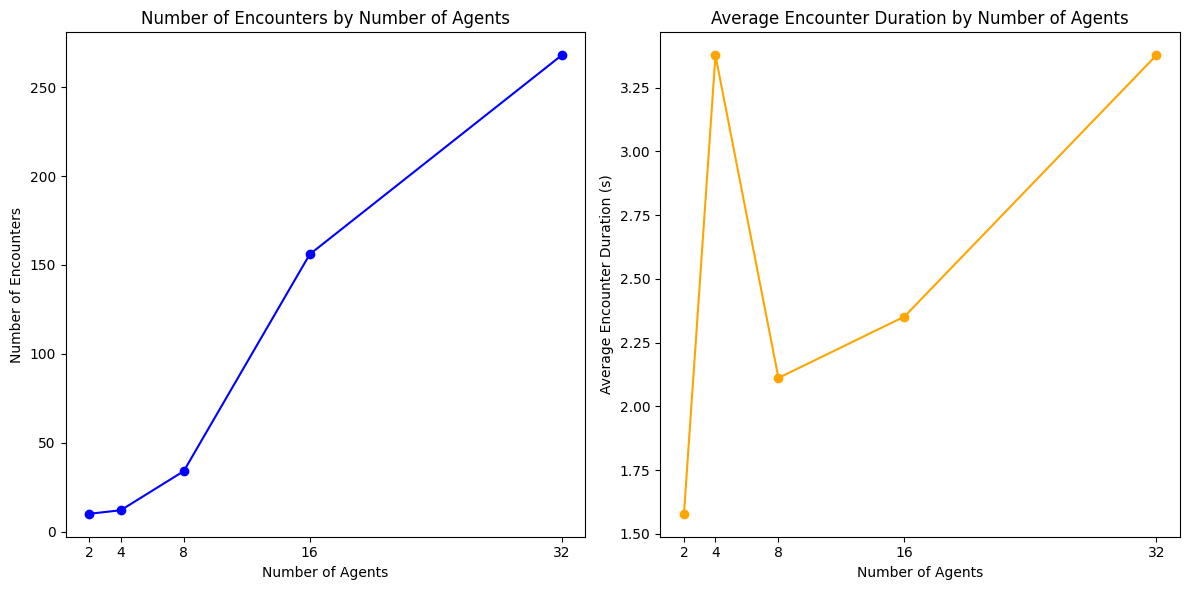

In [3]:
#plot the number of encounters and average time difference
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 6))

# Prepare x and y values
x = [d['num_agents'] for d in data_encounters]
y_encounters = [d['num_encounters'] for d in data_encounters]
y_avg_time = [d['avg_time_diff'] for d in data_encounters]

plt.subplot(1, 2, 1)
plt.plot(x, y_encounters, marker='o', linestyle='-', color='blue')
plt.xlabel('Number of Agents')
plt.ylabel('Number of Encounters')
plt.title('Number of Encounters by Number of Agents')
plt.xticks(x)  # Show only the specific agent numbers

plt.subplot(1, 2, 2)
plt.plot(x, y_avg_time, marker='o', linestyle='-', color='orange')
plt.xlabel('Number of Agents')
plt.ylabel('Average Encounter Duration (s)')
plt.title('Average Encounter Duration by Number of Agents')
plt.xticks(x)  # Show only the specific agent numbers

plt.tight_layout()
plt.show()

## User's Influence

Separately from the experiments performed above, we recorded a short session where a user utilizes a user-controlled agent (cube shape) to alter the sonic environment. You can watch the corresponding video in `data/user_influence/example_1_recording.mp4`.

We can study the behaviour of the user quantitatively through properties from the objects that can be manipulated; in this case, the object is the user-controlled agent. In that regard, you will find below through plots:

* The position of the user from different perspectives, and,
* The encounters over time.

As the main goal of the system is producing sound, which is expected to be musical to some extent, we can analyse the audio signal of the session. For this purpose, we captured the audio and video from the session with a screen recording tool, and we extracted the audio to plot:

* The audio waveform.
* The spectrogram, particularly a CTQ spectrogram, to identify musical frequencies more clearly.

On top of these plots, we draw user activity, as the distance over time from the position of the user to the center of the world (position vector magnitude), and the encounters over time. With that information, we can, in the first place, by observation, identify how the user influences the behaviour of the swarm in terms of the sound output.

A task for you, if you have some time, would be to answer the following question:

* **How does the user activity influence the encounters of autonomous agents?**

We can discuss how to solve this question in the workshop.



In [4]:
user_influence_file = "data/user_influence/ims_2025-06-05_12-12-00.csv"

################### EXTRACT USER CONTROLLED AGENT DATA ###################

#Read the CSV file
user_df = pd.read_csv(user_influence_file)

#Get the start time
start_time = user_df['time'].min()

# Filter messages that contain '/data/test'
user_controlled_agent_df = user_df[user_df['data'].str.contains('1 /agents/position/id 6')].copy()
# Extract x, y, z positions from the 'msg_content' column
user_controlled_agent_df[['x', 'y', 'z']] = user_controlled_agent_df['data'].str.extract(
    r'1 /agents/position/id 6 ([\-\d\.]+) ([\-\d\.]+) ([\-\d\.]+)'
).astype(float)

#Calculate the magnitude of the position vector and convert from mm to m
user_controlled_agent_df['magnitude_m'] = (user_controlled_agent_df[['x', 'y', 'z']].pow(2).sum(axis=1).pow(0.5)) / 1000

# Calculate the actual time from the start time
user_controlled_agent_df['time'] = (user_controlled_agent_df['time'] - start_time)

# Create a DataFrame for user-controlled encounters
user_controlled_encounters_df = create_encounter_df(user_influence_file)
user_controlled_encounters_df = user_controlled_encounters_df[user_controlled_encounters_df['agent'] == 6]
user_controlled_encounters_df['time_in'] = user_controlled_encounters_df['time_in'] - start_time
user_controlled_encounters_df['time_out'] = user_controlled_encounters_df['time_out'] - start_time



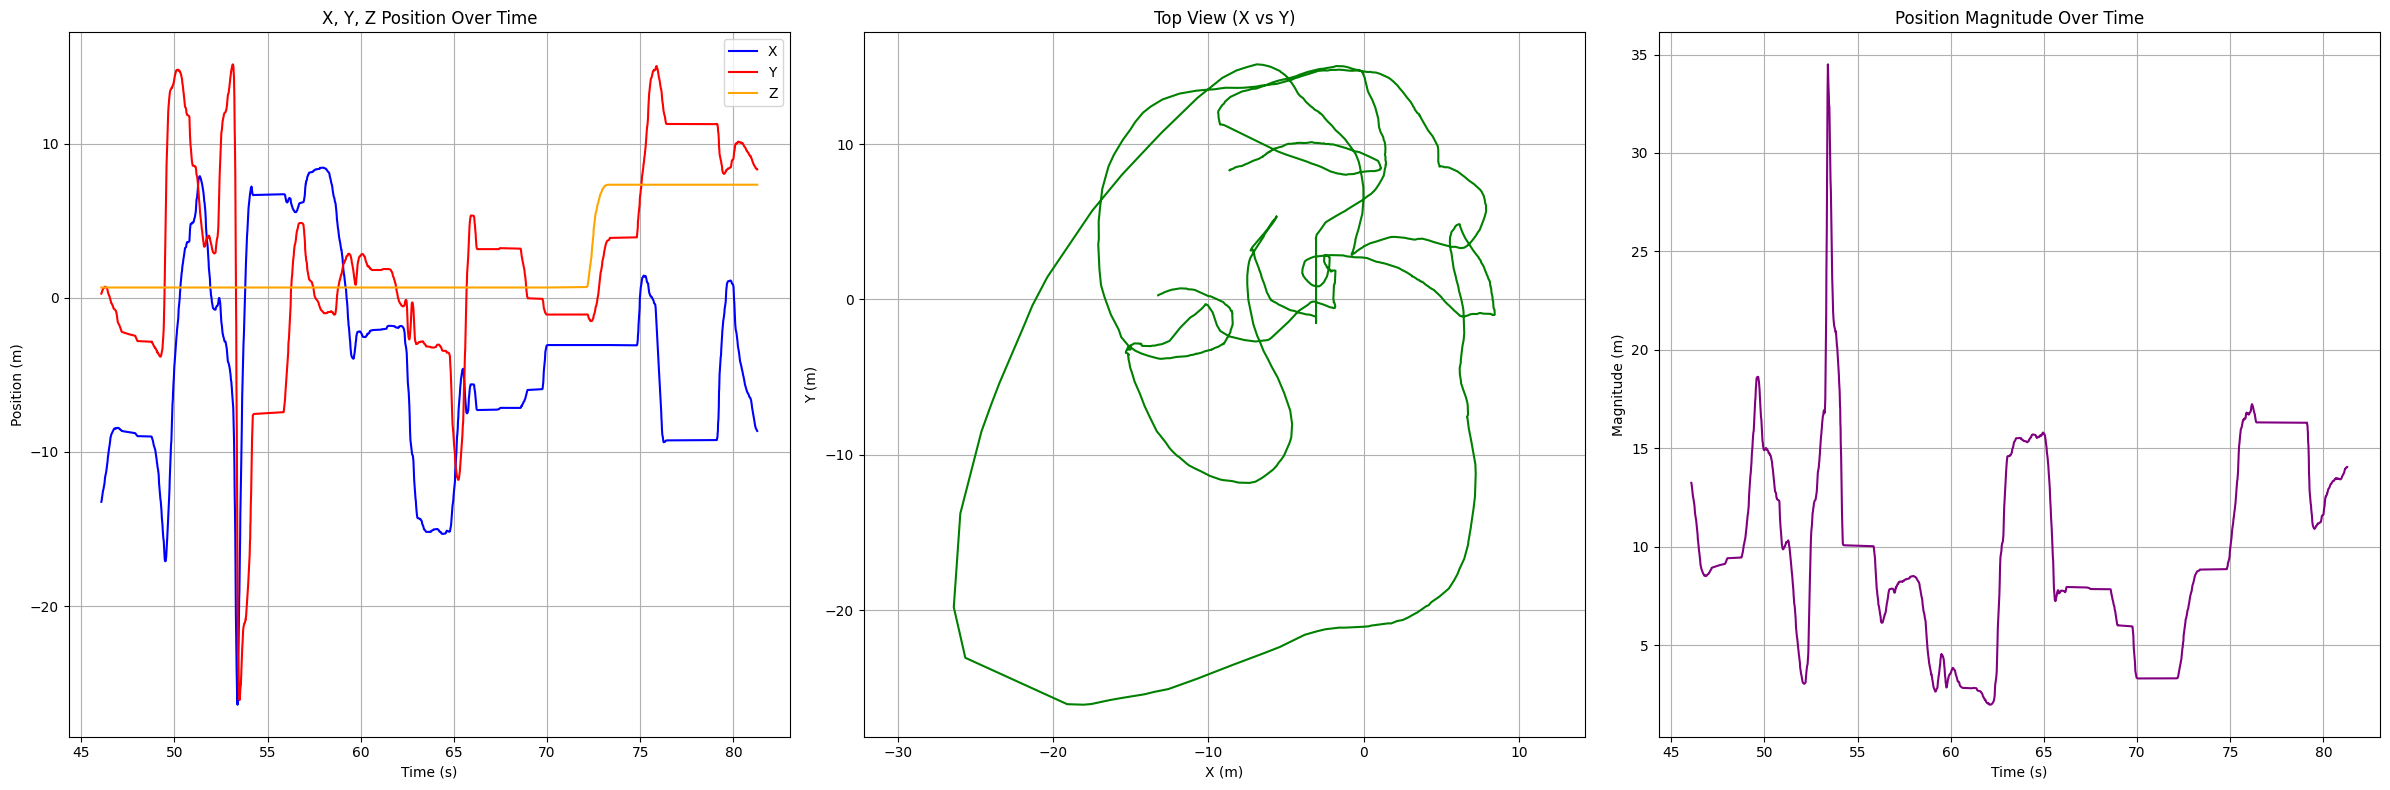

In [5]:
# Plot x, y, z individually, then all together, then in pairs (x,y), (y,z), then the magnitude (in meters) for the user-controlled agent
plt.figure(figsize=(24, 8))

# X, Y, Z together
plt.subplot(1, 3, 1)
plt.plot(user_controlled_agent_df['time'], user_controlled_agent_df['x'] / 1000, label='X', color='blue')
plt.plot(user_controlled_agent_df['time'], user_controlled_agent_df['y'] / 1000, label='Y', color='red')
plt.plot(user_controlled_agent_df['time'], user_controlled_agent_df['z'] / 1000, label='Z', color='orange')
plt.xlabel('Time (s)')
plt.ylabel('Position (m)')
plt.title('X, Y, Z Position Over Time')
plt.legend()
plt.grid()

# X vs Y (top view)
plt.subplot(1, 3, 2)
plt.plot(user_controlled_agent_df['x'] / 1000, user_controlled_agent_df['y'] / 1000, color='green')
plt.xlabel('X (m)')
plt.ylabel('Y (m)')
plt.title('Top View (X vs Y)')
plt.axis('equal')
plt.grid()


# Magnitude over time
plt.subplot(1, 3, 3)
plt.plot(user_controlled_agent_df['time'], user_controlled_agent_df['magnitude_m'], color='purple')
plt.xlabel('Time (s)')
plt.ylabel('Magnitude (m)')
plt.title('Position Magnitude Over Time')
plt.grid()

plt.tight_layout()
plt.show()


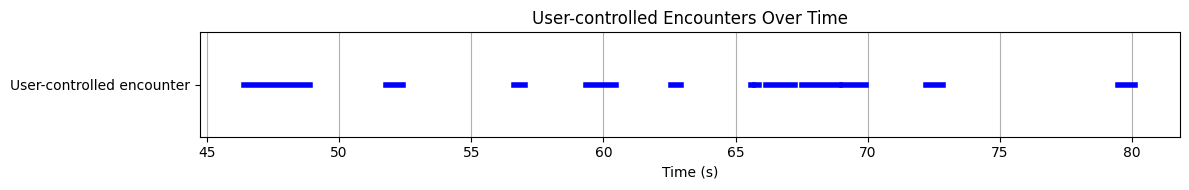

In [6]:
# Plot the user-controlled encounters
plt.figure(figsize=(12, 2))
for _, row in user_controlled_encounters_df.iterrows():
    plt.plot([row['time_in'], row['time_out']], [0, 0], color='blue', linewidth=4)
plt.xlabel('Time (s)')
plt.yticks([0], ['User-controlled encounter'])
plt.title('User-controlled Encounters Over Time')
plt.grid(axis='x')
plt.tight_layout()
plt.show()


In [7]:
import moviepy as mp
import librosa
import numpy as np
from io import BytesIO
import soundfile as sf

video_file = "data/user_influence/example_1_recording.mp4"

################### Audio EXTRACTION ###################

# Load the video file
video = mp.VideoFileClip(video_file)

# Extract the audio
audio = video.audio

# Read the entire audio data
all_audio_data = audio.to_soundarray(fps=audio.fps)

# Convert the sliced audio data to a BytesIO object
audio_buffer = BytesIO()
sf.write(audio_buffer, all_audio_data, samplerate=audio.fps, format='WAV')
audio_buffer.seek(0)

# Load the audio slice with librosa
audio_data, sr = librosa.load(audio_buffer, sr=None)

# Normalize the audio data
audio_data = librosa.util.normalize(audio_data)

In [8]:
import numpy as np
import librosa.display
import matplotlib.pyplot as plt

# Plot the waveform and spectrogram for a given sound sample array and save the figures as pdf files
def plot_waveform_and_spectrogram(sound_samples, spectrogram, sr):
    #Expand the user_controlled_agent_df to cover the sound_samples length
    user_controlled_time = np.insert(user_controlled_agent_df['time'].values, 0, 0)# start point
    user_controlled_time = np.append(user_controlled_time, len(sound_samples) / sr)  # end point
    user_controlled_magnitude = user_controlled_agent_df['magnitude_m'].values
    user_controlled_magnitude = np.insert(user_controlled_agent_df['magnitude_m'].values, 0, user_controlled_magnitude[0]) #start point
    user_controlled_magnitude = np.append(user_controlled_magnitude, user_controlled_magnitude[-1])  # end point
    # Normalize the magnitude to [-1, 1] for overlay
    user_controlled_magnitude = 2 * (user_controlled_magnitude - user_controlled_magnitude.min()) / (user_controlled_magnitude.max() - user_controlled_magnitude.min()) - 1

    plt.figure(figsize=(10, 6))
    librosa.display.waveshow(sound_samples, sr=sr, x_axis='s')
    plt.plot(user_controlled_time, user_controlled_magnitude, color='purple')
    for _, row in user_controlled_encounters_df.iterrows():
        plt.plot([row['time_in'], row['time_out']], [-1, -1], color='blue', linewidth=4)
    plt.title('Waveform')
    plt.xlabel('Time (s)')
    plt.ylabel('Amplitude')
    plt.show()

    plt.figure(figsize=(10, 4))
    librosa.display.specshow(spectrogram, sr=sr, x_axis='s', y_axis='cqt_note')
    plt.colorbar(format='%+2.0f dB')
    plt.title('CQT Spectrogram')
    plt.xlabel('Time (s)')
    plt.ylabel('Note')

    # Overlay user_controlled_magnitude (normalized to [-1, 1]) on top of the spectrogram
    ax = plt.gca()
    ax2 = ax.twinx()
    ax2.plot(user_controlled_time, user_controlled_magnitude, color='cyan', linewidth=2, alpha=0.7, label='U-C Agent: Position Magnitude')
    # Plot user-controlled encounters
    first_encounter = True
    for _, row in user_controlled_encounters_df.iterrows():
        if first_encounter:
            first_encounter = False
            ax2.plot([row['time_in'], row['time_out']], [-1, -1], color='lime', linewidth=8, label="U-C Agent: Encounters' Duration")
        else:
            ax2.plot([row['time_in'], row['time_out']], [-1, -1], color='lime', linewidth=8)
            
    ax2.set_ylim(-1, 1)
    #ax2.set_ylabel('User Magnitude (norm)')
    ax2.set_yticks([-1, 0, 1])
    ax2.legend(loc='upper left')

    #Save ax2 in pdf format
    save_file = False
    if save_file:
        plt.tight_layout()
        plt.savefig("user_controlled_agent_spectrogram.pdf", format='pdf', bbox_inches='tight')

    plt.show()

    


-80.0


C:\Users\pitte\AppData\Local\Temp\ipykernel_2272\90856035.py:17: FutureWarning: waveshow() keyword argument 'x_axis' has been renamed to 'axis' in version 0.10.0.
	This alias will be removed in version 1.0.
  librosa.display.waveshow(sound_samples, sr=sr, x_axis='s')


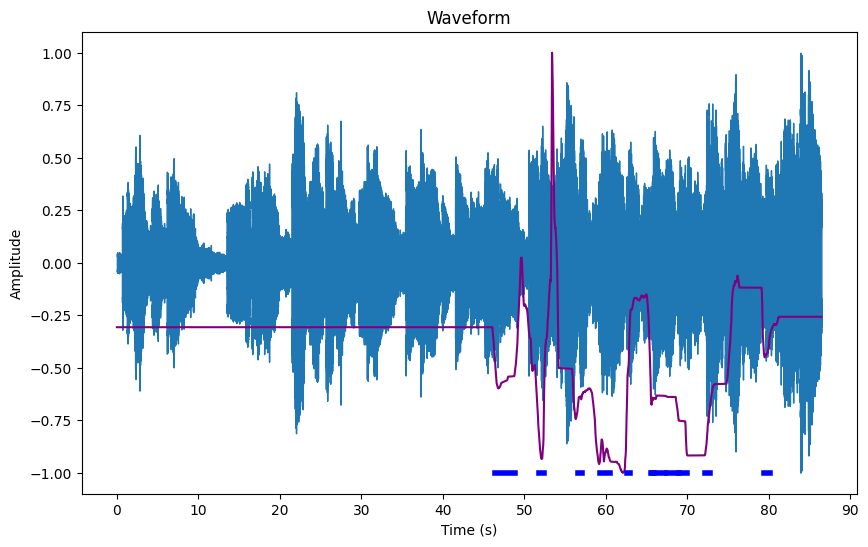

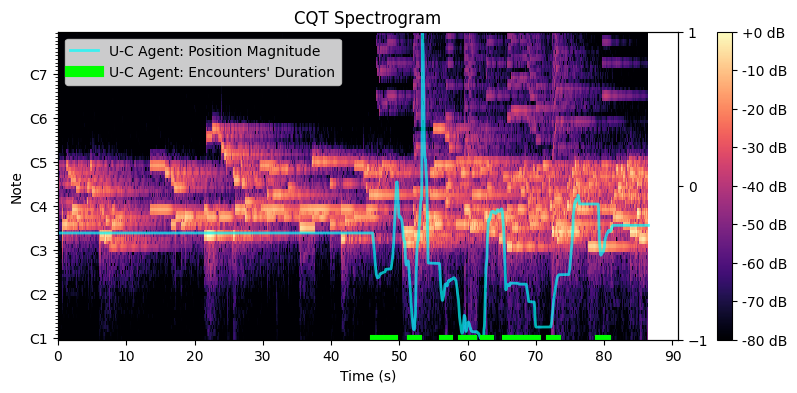

In [9]:
#Using CQT
spectrogram_cqt = librosa.amplitude_to_db(np.abs(librosa.cqt(audio_data, sr=sr)), ref=np.max)
print(min(spectrogram_cqt[0]))
plot_waveform_and_spectrogram(audio_data, spectrogram_cqt, sr)